CISC 340- Lab 3

To implement the Dijkstra and A* algorithams. So first of all need to store graph data using nodes and edges. Here each node represents a location in graph and coordinate information allows the program to calculate edge weights using Euclidean distance. 
Rough idea is each node has this data node ID or name, x coordinate, y coordinate, list of neighbouring nodes that connected node. Edge weights representing the cost to visit each neighbor node. 
Add further, graph will sotre collection of the nodes, typically list or dictionary structure. It is similar as adjency list representation that we store data into code format.

Example of this intenal structure:
Node A(X1, Y1) - connected to Node B distance and Node C distance
Node B(X2, Y2) - connected to Node A distance and Node C distance
Node C(X3, Y3) - connected to Node A distance and Node B distance
Each connection between nodes represents an edge in the graph and weight of the edge using coordinate of two nodes. 

When the robust_output flag is true, program prints extra information about how algorithm works. This help us the undersatnd how algorithm explores the graph and finds the shortest path. Before the search starts program prints basic information such as start node, end node and total number of nodes. It may also show node coordinates and connections with distance. Program prints the current node being visited and distace from the start node during the search. Neighbor nodes also checked. If shorter path found, program prints the updated distance for A* algorithm. The program prints the final shortest path, total distance and numbers of nodes visited. That help us to understand how the algorithm reached the final result. 

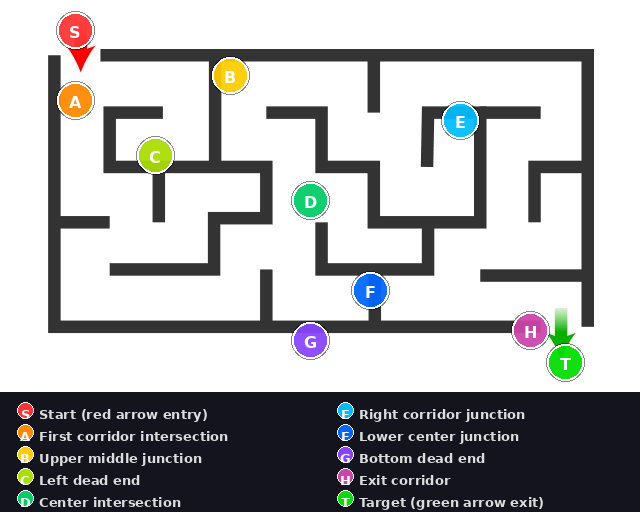

In [23]:
from IPython.display import Image
Image(filename=r'C:\Users\bhavi\Desktop\maze with nodes .png')

To translate maze into graph struture. Frist focus on the important maze locations as nodes and walkable corridors between them as edges. In maze to graph converstaion nodes typically placed at: Red arrow is start point, Green arrow is end point. Intersactions where multiple paths meet. Turns and dead ends beacause suggest by assignment. 

S-Start node with red arrow, 
A-First corridor intersaction,
B-Upper middle junction,
C-Left dead end,
D-Center intersaction,
E-Right corridor juction,
F-Lower center junction,
G-Bottom dead end,
H-Exit corridor,
T- Target node with green arrow. 

Adjency list where each node stores its neighbors.
S: A
A: S,B,C
B: A,D
C: A
D: B,E,F
E: D,H
F: D,G
G: F
H: E,T
T: H



In [13]:
import heapq
import math
from itertools import count
class Node:
    def __init__(self, name, x, y):
        self.name = name
        self.x = x
        self.y = y
        self.neighbors = []
    def __lt__(self, other):
        return self.name < other.name
    def __hash__(self):
        return hash(self.name)
    def __eq__(self, other):
        return isinstance(other, Node) and self.name == other.name
    def __repr__(self):
        return self.name

In [14]:
class Graph:
    def __init__(self):
        self.nodes = []
    def add_node(self,node):
        self.nodes.append(node)
    def add_edge(self,n1,n2):
        weight = euclidean_distance(n1,n2)
        n1.neighbors.append((n2,weight))
        n2.neighbors.append((n1,weight))

In [15]:
def euclidean_distance(n1, n2):
    return math.sqrt((n1.x - n2.x)**2 + (n1.y - n2.y)**2)

In [16]:
def searchDijkstra(graph,start,end,robust_output=False):
    pq=[] #create priority queue to store nodes
    counter=count() #counter used to break priority queue
    dist={node:math.inf for node in graph.nodes} #create dictionary to store shortest distance
    prev={node:None for node in graph.nodes} #create dictionary to store previous node in path
    dist[start]=0 #it is start with zero
    heapq.heappush(pq,(0,next(counter),start)) #add start node to priority queue
    if robust_output:
        print("Starting Dijkstra Search")
        print("Start Node:",start.name)
        print("End Node:",end.name)
        print()
    while pq: #continue searching while priority queue is not empty
        current_dist,_,current=heapq.heappop(pq) #remove with smallest distance
        if robust_output:
            print("Visiting Node:",current.name)
            print("Distance:",current_dist)
        if current==end: #if reached the goal node, stop the search
            break
        for neighbor,weight in current.neighbors: #check al neighbor of current node
            new_dist=current_dist+weight #compute new distance through current node
            if new_dist < dist[neighbor]: #if new path is shorter than previously known path
                dist[neighbor]=new_dist #update distance with shortest path
                prev[neighbor]=current #record previous node for path reconstruction
                heapq.heappush(pq,(new_dist,next(counter),neighbor)) #add neighbor to priority queue for future exploration
                if robust_output:
                    print("Updating:",neighbor.name,
                          "Distance:",new_dist)
        if robust_output:
            print()
    path=[] #reconstruct shortest path from end to start
    node=end
    while node:
        path.append(node)
        node=prev[node]
    path.reverse() #reverse path so it goes from start to end
    if robust_output:
        print("Shortest Path:",
              " -> ".join(n.name for n in path))
        print("Path Length:",dist[end])
    return path,dist[end] #return shortest path and total distance

In [17]:
S = Node("S",0,8)
A = Node("A",2,8)
B = Node("B",4,8)
C = Node("C",2,10)
D = Node("D",4,6)
E = Node("E",6,6)
F = Node("F",4,4)
G = Node("G",4,2)
H = Node("H",8,6)
T = Node("T",10,6)
g=Graph()
for n in [S,A,B,C,D,E,F,G,H,T]:
    g.add_node(n)
g.add_edge(S,A)
g.add_edge(A,B)
g.add_edge(A,C)
g.add_edge(B,D)
g.add_edge(D,E)
g.add_edge(D,F)
g.add_edge(E,H)
g.add_edge(F,G)
g.add_edge(H,T)
searchDijkstra(g,S,T,True)

Starting Dijkstra Search
Start Node: S
End Node: T

Visiting Node: S
Distance: 0
Updating: A Distance: 2.0

Visiting Node: A
Distance: 2.0
Updating: B Distance: 4.0
Updating: C Distance: 4.0

Visiting Node: B
Distance: 4.0
Updating: D Distance: 6.0

Visiting Node: C
Distance: 4.0

Visiting Node: D
Distance: 6.0
Updating: E Distance: 8.0
Updating: F Distance: 8.0

Visiting Node: E
Distance: 8.0
Updating: H Distance: 10.0

Visiting Node: F
Distance: 8.0
Updating: G Distance: 10.0

Visiting Node: H
Distance: 10.0
Updating: T Distance: 12.0

Visiting Node: G
Distance: 10.0

Visiting Node: T
Distance: 12.0
Shortest Path: S -> A -> B -> D -> E -> H -> T
Path Length: 12.0


([S, A, B, D, E, H, T], 12.0)

Start implementation of A* algorithm

In [18]:
def heuristic(n1, n2):
    return math.sqrt((n1.x - n2.x)**2 + (n1.y - n2.y)**2)

In [19]:
def searchAStar(graph, start, end, robust_output=False):
    pq = []
    counter = count()
    g = {node: math.inf for node in graph.nodes}   # cost from start
    f = {node: math.inf for node in graph.nodes}   # total estimated cost
    previous = {node: None for node in graph.nodes}
    g[start] = 0
    f[start] = heuristic(start, end)
    heapq.heappush(pq, (f[start], next(counter), start))
    if robust_output:
        print("Starting A* Search")
        print("Start Node:", start.name)
        print("End Node:", end.name)
        print()
    while pq:
        current_f, _, current = heapq.heappop(pq)
        if robust_output:
            print("Visiting Node:", current.name)
            print("g(n):", g[current],
                  "h(n):", heuristic(current, end),
                  "f(n):", current_f)
        if current == end:
            break
        for neighbor, weight in current.neighbors:
            tentative_g = g[current] + weight
            if tentative_g < g[neighbor]:
                previous[neighbor] = current
                g[neighbor] = tentative_g
                f[neighbor] = tentative_g + heuristic(neighbor, end)
                heapq.heappush(pq, (f[neighbor], next(counter), neighbor))
                if robust_output:
                    print("Updating:", neighbor.name,
                          "g(n):", g[neighbor],
                          "f(n):", f[neighbor])
        if robust_output:
            print()
    # Reconstruct path
    path = []
    node = end
    while node:
        path.append(node)
        node = previous[node]
    path.reverse()
    if robust_output:
        print("Shortest Path:", " -> ".join(n.name for n in path))
        print("Path Length:", g[end])
    return path, g[end]

In [20]:
S = Node("S",0,8)
A = Node("A",2,8)
B = Node("B",4,8)
C = Node("C",2,10)
D = Node("D",4,6)
E = Node("E",6,6)
F = Node("F",4,4)
G = Node("G",4,2)
H = Node("H",8,6)
T = Node("T",10,6)
g=Graph()
for n in [S,A,B,C,D,E,F,G,H,T]:
    g.add_node(n)
g.add_edge(S,A)
g.add_edge(A,B)
g.add_edge(A,C)
g.add_edge(B,D)
g.add_edge(D,E)
g.add_edge(D,F)
g.add_edge(E,H)
g.add_edge(F,G)
g.add_edge(H,T)
path, distance = searchAStar(g, S, T, True)

Starting A* Search
Start Node: S
End Node: T

Visiting Node: S
g(n): 0 h(n): 10.198039027185569 f(n): 10.198039027185569
Updating: A g(n): 2.0 f(n): 10.246211251235321

Visiting Node: A
g(n): 2.0 h(n): 8.246211251235321 f(n): 10.246211251235321
Updating: B g(n): 4.0 f(n): 10.32455532033676
Updating: C g(n): 4.0 f(n): 12.94427190999916

Visiting Node: B
g(n): 4.0 h(n): 6.324555320336759 f(n): 10.32455532033676
Updating: D g(n): 6.0 f(n): 12.0

Visiting Node: D
g(n): 6.0 h(n): 6.0 f(n): 12.0
Updating: E g(n): 8.0 f(n): 12.0
Updating: F g(n): 8.0 f(n): 14.32455532033676

Visiting Node: E
g(n): 8.0 h(n): 4.0 f(n): 12.0
Updating: H g(n): 10.0 f(n): 12.0

Visiting Node: H
g(n): 10.0 h(n): 2.0 f(n): 12.0
Updating: T g(n): 12.0 f(n): 12.0

Visiting Node: T
g(n): 12.0 h(n): 0.0 f(n): 12.0
Shortest Path: S -> A -> B -> D -> E -> H -> T
Path Length: 12.0


Result of both algorithm is same but when we check result we have to look all the data. From the data I understand it is efficiency that made both function different. First diffrence is A* function uses formula f(n)=g(n)+h(n). So this function use two possible way one g(a) is actual cost from start node to current node and h(n) is the estimated cost from the node to the goal. h(n) is heuristic. from the data we have after the run the both function. Dijkstra visits node C, node F and node G. A* completely ignore them because the h(n) value for that nodes likely made their total f(n) too high so algorithm knows that it is worng path.

I imagine Dijkstra function like wave in pond. When we throw stone in pond it is made circle until all circles complete. So here is Dijkstra function same way it hits all dircetion equally until reach the destination. This is the reason why it is visited all node including C and G. A* function is like intilligently search path towards goal. It is targeting that node their h(n) value is decreasing so it understand that when values decreasing they are more closer to direction. 

While A* visited limited nodes. It is perform more math at every step. In realworld it is save time by visiting fewer nodes. When we see data we have A* function is reached same conclusion using informed search faster then Dijkstra function. For efficiency and problem solving A* function is better then Dijkstra. 